<a href="https://colab.research.google.com/github/saniya2305/Instagram-Data-Analysis/blob/main/Zomato_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import files
uploaded = files.upload()

Saving zomato.csv.zip to zomato.csv (1).zip


In [11]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/zomato_data')

os.listdir('/content/zomato_data')

['zomato.csv']

In [12]:
df = pd.read_csv('/content/zomato_data/zomato.csv', encoding='latin1')
df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [13]:
df.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [14]:
df.isnull().sum()

,0
address,17
name,16
online_order,19
book_table,58
rate,7838
votes,78
phone,1296
location,126
rest_type,338
dish_liked,28225


In [16]:
df = df[df['rate'] != 'NEW']
df = df[df['rate'] != '-']

df['rate'] = df['rate'].astype(str).str.split('/').str[0]
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [17]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '')
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

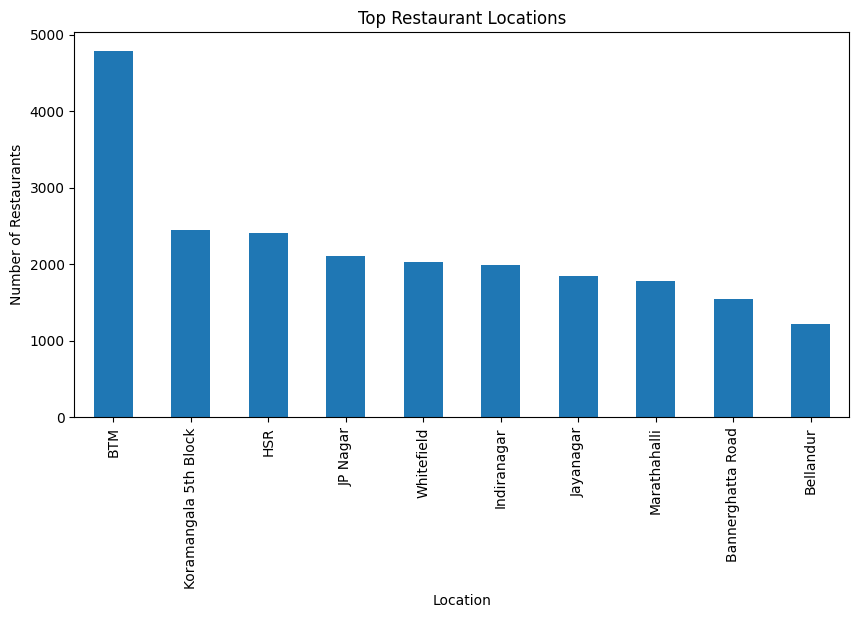

In [18]:
df['location'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Restaurant Locations")
plt.xlabel("Location")
plt.ylabel("Number of Restaurants")
plt.show()

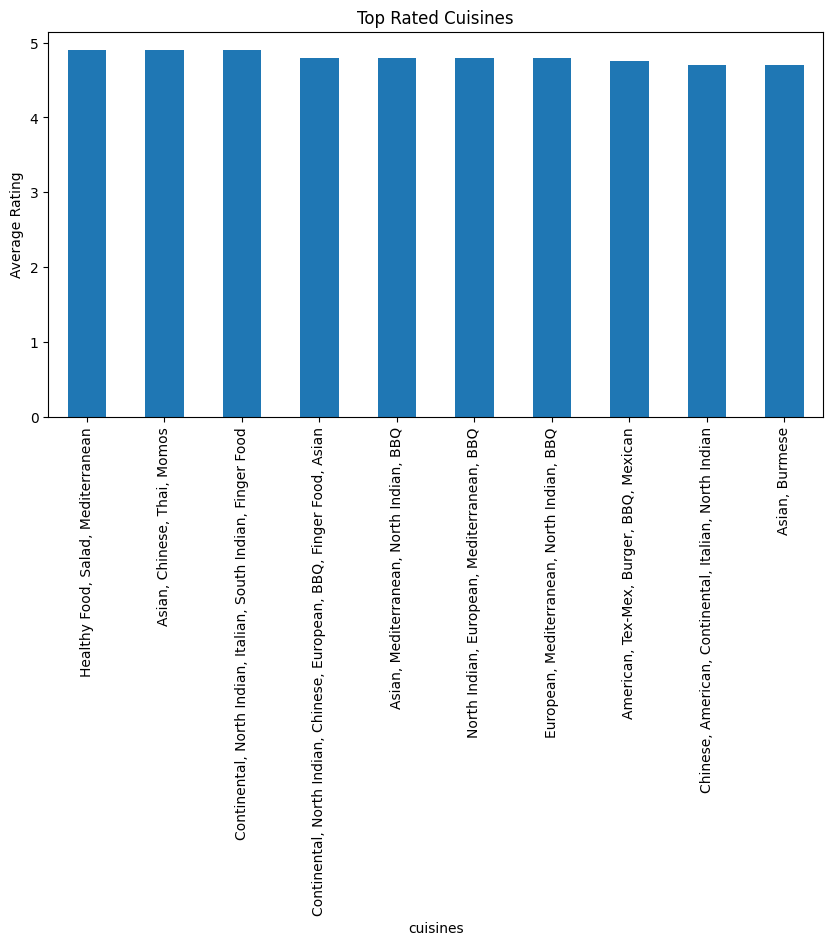

In [19]:
df.groupby('cuisines')['rate'].mean().sort_values(ascending=False).head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Rated Cuisines")
plt.ylabel("Average Rating")
plt.show()

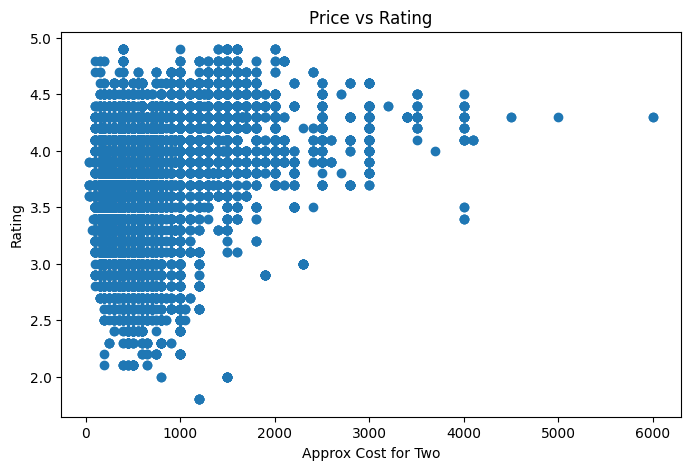

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(df['approx_cost(for two people)'], df['rate'])
plt.title("Price vs Rating")
plt.xlabel("Approx Cost for Two")
plt.ylabel("Rating")
plt.show()

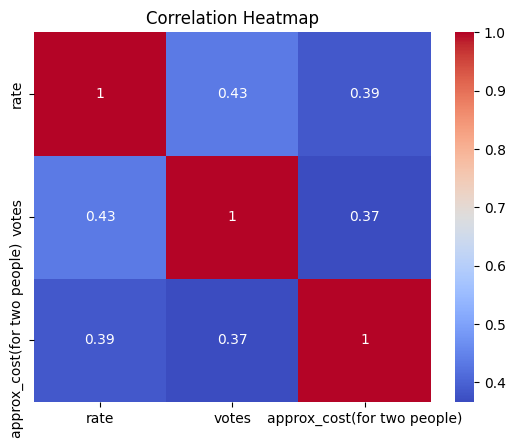

In [23]:
numeric_df = df[['rate', 'votes', 'approx_cost(for two people)']].copy()

numeric_df['rate'] = pd.to_numeric(numeric_df['rate'], errors='coerce')
numeric_df['votes'] = pd.to_numeric(numeric_df['votes'], errors='coerce')
numeric_df['approx_cost(for two people)'] = pd.to_numeric(
    numeric_df['approx_cost(for two people)'], errors='coerce'
)

numeric_df = numeric_df.dropna()

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

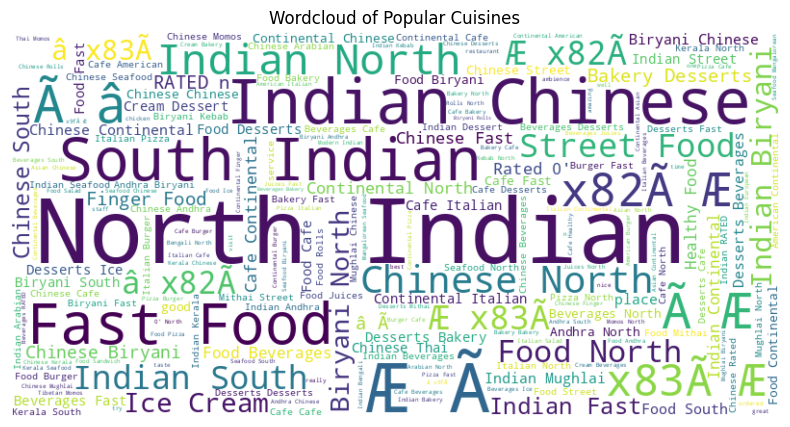

In [27]:
!pip install wordcloud

from wordcloud import WordCloud

text = " ".join(df['cuisines'].dropna().astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Wordcloud of Popular Cuisines")
plt.show()

Insights:-

1.Some locations have a higher number of restaurants, showing strong customer demand and market hotspots.

2.Popular cuisines received better ratings, indicating customer preference for certain food categories.

3.Higher price does not always result in higher ratings, showing affordability also matters.

4.Restaurants with more customer votes generally had better ratings and visibility.

5.Cuisine type, location, and customer engagement are important factors affecting restaurant performance.

Recommendations:-

1.Partner with highly rated restaurants in popular locations to attract more users.

2.Promote trending cuisines through targeted campaigns and social media content.

3.Highlight affordable top-rated restaurants for budget-conscious customers.

4.Use customer reviews and ratings to improve personalized recommendations.

5.Launch location-based offers and discounts in high-demand areas.

Conclusion:-

The Zomato dataset analysis shows that restaurant ratings are influenced by cuisine type, customer votes, and location. Popular areas and preferred cuisines attract higher engagement, while price alone does not determine customer satisfaction. A data-driven strategy focused on partnerships, promotions, and customer preferences can help improve platform growth and user experience.